In [57]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
import os

tf.config.list_physical_devices('GPU')

[]

# importing data

In [4]:
df = pd.read_csv('../camels_info/camels_parameters.csv')
df

,Name,Omega_m,sigma_8,A_SN1,A_AGN1,A_SN2,A_AGN2,seed
0,LH_0,0.3090,0.9790,3.11234,1.12194,0.66850,0.53182,0
1,LH_1,0.3026,0.9394,3.42001,3.96137,1.03311,1.16070,1
2,LH_2,0.4282,0.7530,0.70613,0.37423,1.96292,0.62720,2
3,LH_3,0.1906,0.6286,1.60882,0.39887,0.86634,0.86634,3
4,LH_4,0.1382,0.6874,1.19914,0.27586,0.82188,0.91700,4
...,...,...,...,...,...,...,...,...
1092,CV_26,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,27
1093,EX_0,0.3000,0.8000,1.00000,1.00000,1.00000,1.00000,13560
1094,EX_1,0.3000,0.8000,1.00000,100.00000,1.00000,1.00000,13560
1095,EX_2,0.3000,0.8000,100.00000,1.00000,1.00000,1.00000,13560


In [5]:
df.loc[df['Name'] == "LH_0"].values[0][1:-1]

array([0.309, 0.979, 3.11234, 1.12194, 0.6685, 0.53182], dtype=object)

In [6]:
out_dir = "../power_spectra/CO/20230313_no_std/"

def get_LH_files():
    fils = list(map(lambda fil: fil[:-4], \
               (filter(lambda fil: f"LH_" in fil, os.listdir(out_dir)))))
    sorter_1P_fils = lambda filname: int(filname.split('_')[-1].replace('n', '-'))
    return sorted(fils, key=sorter_1P_fils)

sim_names = get_LH_files()
sim_names[:5], sim_names[-5:], len(sim_names)

(['LH_0', 'LH_1', 'LH_2', 'LH_3', 'LH_4'],
 ['LH_995', 'LH_996', 'LH_997', 'LH_998', 'LH_999'],
 1000)

In [7]:
if "LH_603" in sim_names:
    sim_names.remove("LH_603")

In [8]:
non_nan_range = np.arange(24, 46)
all_curves = np.array([])
k_set = None
for fil in sim_names:
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    nan_sum = sum(sum(np.isnan(np.array(list(curves.values()))))[non_nan_range])
    assert (nan_sum == 0), fil
    assert (sum(np.isnan(np.array(list(curves.values()))))[23] == 34)
    assert (sum(np.isnan(np.array(list(curves.values()))))[46] == 34)
    if k_set is None:
        k_set = ks[0]
    for k in ks.values():
        assert((k == k_set).all()), print(fil, k, k_set)

In [70]:
sim_names = sim_names[:603] + ["LH_603"] + sim_names[604:]
sim_names[600:605]

['LH_600', 'LH_601', 'LH_602', 'LH_603', 'LH_605']

In [9]:
num_samples = len(sim_names)
print(num_samples)
non_nan_range = np.arange(24, 46)
all_curves = np.zeros((num_samples, 34, 22)) + np.nan
all_cosmologies = np.zeros((num_samples, 6)) + np.nan
for ind, fil in enumerate(sim_names):
    with np.load(out_dir + fil + ".npz", allow_pickle=True) as data:
        curves = data['curves'].item()
        redshifts = data['redshifts'].item()
        ks = data['ks'].item()
    all_curves[ind] = np.array(list(curves.values()))[:, non_nan_range]
    all_cosmologies[ind] = df.loc[df['Name'] == fil].values[0][1:-1]

999


In [10]:
print(all_curves.shape, all_cosmologies.shape)
print(np.sum(np.isnan(all_curves)), np.sum(np.isnan(all_cosmologies)))

(999, 34, 22) (999, 6)
0 0


In [72]:
train_split, val_split, test_split = int(0.85*num_samples), \
            int(0.10*num_samples) + 1, int(0.05*num_samples) + 1

print(train_split, val_split, test_split, train_split+val_split+test_split)

train_x, val_x, test_x = np.split(all_curves, [train_split, train_split+val_split])
train_y, val_y, test_y = np.split(all_cosmologies, [train_split, train_split+val_split])

print(train_x.shape, val_x.shape, test_x.shape)
print(train_y.shape, val_y.shape, test_y.shape)

849 100 50 999
(849, 34, 22) (100, 34, 22) (50, 34, 22)
(849, 6) (100, 6) (50, 6)


In [ ]:
train_y, val_y, test_y = train_y[:,:2], val_y[:,:2], test_y[:,:2]
print(train_y.shape, val_y.shape, test_y.shape)

(849, 2) (100, 2) (50, 2)


# Basic NN

In [ ]:
# Define the input shape
input_shape = (34, 22) 
# Define the model
output_num = 6
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(512, activation='relu', input_shape=input_shape, return_sequences=True),
    tf.keras.layers.Permute((2, 1)),
    tf.keras.layers.SimpleRNN(512, activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
model.compile(loss='mse', optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=100, validation_data=(val_x, val_y), verbose=2)

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/100


In [95]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

KeyboardInterrupt: 

# CNN

In [94]:
input_shape = (34, 22, 1) 

output_num = 6

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(512, kernel_size=(5, 5), activation='relu', input_shape=input_shape),
  tf.keras.layers.Conv2D(512, kernel_size=(2, 2), activation='relu'),
  tf.keras.layers.Conv2D(512, kernel_size=(3, 3), activation='relu'),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(256, activation='relu'),
  tf.keras.layers.Dense(output_num, activation='linear') # assuming 6 output parameters
])

# Compile the model
# model.compile(loss='mse', optimizer='adam')
model.compile(loss=tf.keras.losses.LogCosh(), optimizer='adam')

# Train the model
history = model.fit(train_x, train_y, epochs=5, validation_data=(val_x, val_y), verbose=1)

# Evaluate the model on the test set
test_loss = model.evaluate(test_x, test_y)
print('Test loss:', test_loss)

model.summary()

Epoch 1/5
27/27 [==============================] - 36s 1s/step - loss: 20.3741 - val_loss: 0.2221
Epoch 2/5
27/27 [==============================] - 35s 1s/step - loss: 0.3266 - val_loss: 0.2199
Epoch 3/5
27/27 [==============================] - 36s 1s/step - loss: 0.1904 - val_loss: 0.1850
Epoch 4/5
27/27 [==============================] - 36s 1s/step - loss: 0.2266 - val_loss: 0.1485
Epoch 5/5
2/2 [==============================] - 0s 101ms/step - loss: 0.1858
Test loss: 0.18582969903945923
Model: "sequential_33"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_49 (Conv2D)          (None, 30, 18, 512)       13312     
                                                                 
 conv2d_50 (Conv2D)          (None, 29, 17, 512)       1049088   
                                                                 
 conv2d_51 (Conv2D)          (None, 27, 15, 512)       2359808   
                 

2/2 [==============================] - 0s 101ms/step


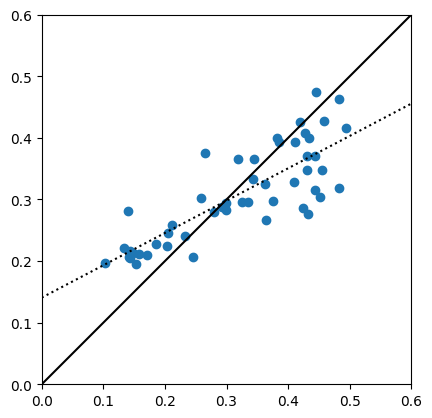

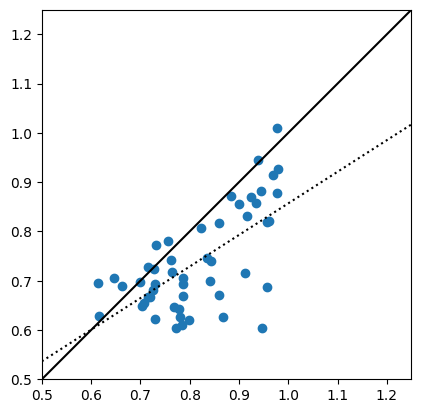

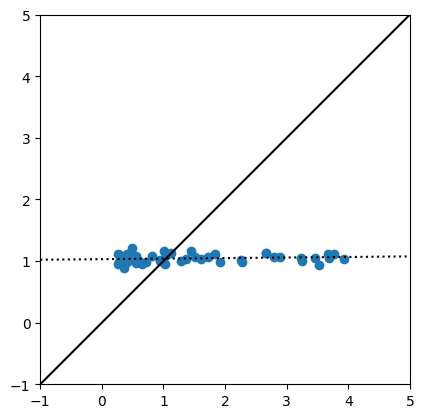

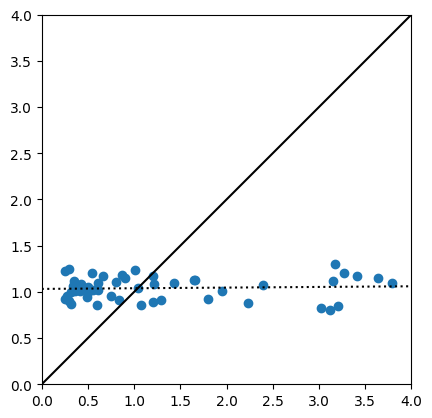

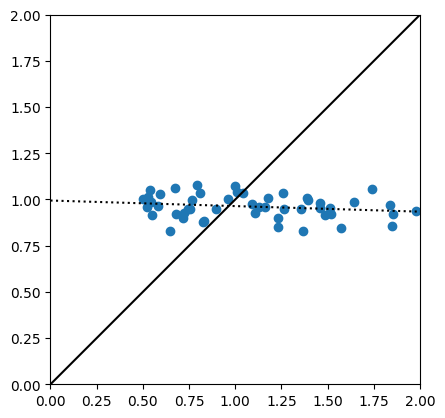

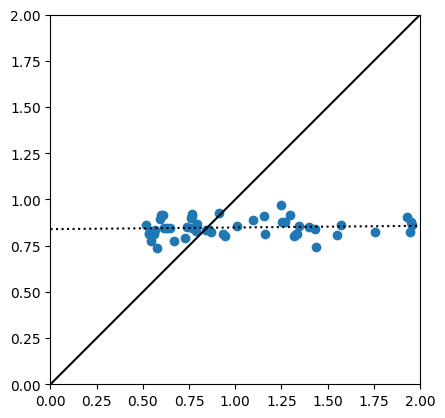

In [96]:
predictions = model.predict(test_x)
upp_lims = [0.6, 1.25, 5, 4, 2, 2]
low_lims = [0, 0.5, -1, 0, 0, 0]
for ind, (low_lim, upp_lim) in enumerate(zip(low_lims, upp_lims)):
    p = np.poly1d(np.polyfit(test_y[:, ind], predictions[:, ind], 1))
    plt.figure()
    plt.scatter(test_y[:, ind], predictions[:, ind])
    plt.plot([low_lim, upp_lim], [low_lim, upp_lim], color="black")
    plt.plot([low_lim, upp_lim], [p(low_lim), p(upp_lim)], color="black", ls=":")
    plt.xlim([low_lim, upp_lim])
    plt.ylim([low_lim, upp_lim])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.show()
    plt.close()

In [84]:
np.sqrt(np.mean(((test_y[:, 0] - predictions[:, 0])) ** 2))

0.04256044561767102

In [85]:
np.sqrt(np.mean(((test_y[:, 1] - predictions[:, 1])) ** 2))

0.095068542699699

In [86]:
np.sqrt(np.mean(((test_y[:, 2] - predictions[:, 2])) ** 2))

1.203129232197273